# Where a hierarchical Bayesian model gets its noise scale from

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/panel_pymc_hierarchical.ipynb)

Part 4 of this series measured GPBoost, which fits a nonlinear fixed part plus a random intercept
per unit, covering 73% of held-out rows with a nominal 90% interval, because its noise variance came
from residuals on rows the trees had already fitted. Its out-of-sample variant did reach 90%, but by
overshooting that variance to 1.33 while the interval still carried no term for the error of the
trees themselves, so two mistakes cancelled.

A hierarchical Bayesian model builds the interval from the posterior instead, which supplies the
missing term directly. This notebook runs it on the same panel, with the same known scales, and asks
two questions: does the interval hold, and what is the number the model calls the noise scale
actually measuring.

The panel, the fixed part and the true scales are identical to part 4, so the GPBoost column here is
directly comparable to the one there.

About five minutes on a laptop CPU, and longer on a free Colab runtime.

In [1]:
# guard on the rarest of the four, or a runtime that already ships pymc skips the rest
try:
    import pymc_bart
except ImportError:
    !pip install -q pymc==6.3.1 pymc-bart==0.13.1 nutpie==0.16.11 gpboost==1.7.4

In [2]:
import time, logging, warnings
import numpy as np, pandas as pd
import pymc as pm, pymc_bart as pmb, arviz as az, gpboost as gpb
import importlib.metadata as meta

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)
pd.set_option("display.width", 220, "display.max_columns", 40)
print(" | ".join(f"{p} {meta.version(p)}" for p in ("pymc", "pymc-bart", "arviz", "gpboost")))

pymc 6.3.1 | pymc-bart 0.13.1 | arviz 1.3.0 | gpboost 1.7.4


## The panel

Identical to part 4: 120 units with 8 training rows each, plus 2 validation and 4 test rows per
unit, and 40 units that never appear in training. The fixed part is Friedman #1 rescaled to a
standard deviation near 2. The unit effect is a random intercept with variance 1.0 and the noise
variance is 1.0, so both true scales are 1.0 and every estimate below sits next to the value it is
trying to recover.

Rows within a unit are independent draws. Real panels usually have serial correlation on top of
this, which this design leaves out.

In [3]:
SB, SE, Z90 = 1.0, 1.0, 1.6448536269514722          # both true scales are 1.0
# these are standard deviations, where part 4 stored the two variances and took roots at the
# draw; identical while both are 1.0, so change both notebooks together if you edit one
NG, T_TR, T_VA, T_TE, NG_NEW = 120, 8, 2, 4, 40
DRAWS, TUNE, CHAINS = 1000, 1000, 4


def F(X):
    f = 10*np.sin(np.pi*X[:, 0]*X[:, 1]) + 20*(X[:, 2]-0.5)**2 + 10*X[:, 3] + 5*X[:, 4]
    return (f - 14.4) / 2.5


def draw(rng, n_groups, n_per, offset, b):
    g = np.repeat(np.arange(n_groups) + offset, n_per)
    X = rng.uniform(size=(len(g), 5))
    return X, g, F(X) + b[g - offset] + rng.normal(0, SE, len(g))


def make(seed):
    rng = np.random.default_rng(seed)
    b = rng.normal(0, SB, NG)
    d = {k: draw(rng, NG, n, 0, b) for k, n in [("train", T_TR), ("val", T_VA), ("test", T_TE)]}
    d["new"] = draw(rng, NG_NEW, T_TR, 10_000, rng.normal(0, SB, NG_NEW))
    return d


def rmse(y, p):
    return float(np.sqrt(np.mean((y - p)**2)))


def interval(y, draws):
    lo, hi = np.percentile(draws, [5, 95], axis=0)
    return float(np.mean((y >= lo) & (y <= hi))), float((hi - lo).mean())


d0 = make(0)
print({k: len(v[2]) for k, v in d0.items()}, "| sd(y) =", round(d0["train"][2].std(), 3))

{'train': 960, 'val': 240, 'test': 480, 'new': 320} | sd(y) = 2.306


## GPBoost, the reference from part 4

Same 20-setting grid as part 4, four tree structures by five round counts, picked on the validation
split. This is the only method in this notebook that gets tuned at all, which is worth remembering
when reading the comparison: the asymmetry runs against the Bayesian models, not for them.

In [4]:
ROUNDS = [50, 100, 200, 400, 800]
STRUCTS = [(8, 20), (31, 20), (31, 50), (63, 10)]
BASE = {"objective": "regression_l2", "learning_rate": 0.05, "verbose": -1}


def gpboost(d, seed):
    Xtr, gtr, ytr = d["train"]
    Xv, gv, yv = d["val"]
    best = None
    t = time.time()
    # one fit per round count on purpose: GPBoost re-estimates the covariance parameters jointly
    # with the trees, and get_cov_pars() only reports the last iteration, so training once to 800
    # and truncating with num_iteration would report the wrong scales for every shorter setting
    for leaves, min_data in STRUCTS:
        params = dict(BASE, num_leaves=leaves, min_data_in_leaf=min_data)
        for m in ROUNDS:
            gp = gpb.GPModel(group_data=gtr, likelihood="gaussian")
            bst = gpb.train(params=params, train_set=gpb.Dataset(Xtr, ytr), gp_model=gp,
                            num_boost_round=m)
            r = rmse(yv, bst.predict(data=Xv, group_data_pred=gv)["response_mean"])
            if best is None or r < best[0]:
                best = (r, bst, np.sqrt(np.asarray(gp.get_cov_pars(), float).ravel()[:2]))
    _, bst, scales = best
    out = {"model": "GPBoost", "seed": seed, "s": scales[0], "s_b": scales[1]}
    for part, key in [("test", "seen"), ("new", "unseen")]:
        X, g, y = d[part]
        p = bst.predict(data=X, group_data_pred=g, predict_var=True)
        mean, sd = p["response_mean"], np.sqrt(np.maximum(p["response_var"], 0.0))
        out[f"rmse_{key}"] = rmse(y, mean)
        out[f"cov_{key}"] = float(np.mean(np.abs(y - mean) <= Z90*sd))
        out[f"width_{key}"] = float(2*Z90*sd.mean())
    X, g, _ = d["test"]
    out["rmse_F"] = rmse(F(X), bst.predict(data=X, group_data_pred=g,
                                           pred_latent=True)["fixed_effect"])
    out["sec"] = time.time() - t          # the whole grid search plus the predictions
    return out

## The two hierarchical models

Both share the random-effects half and differ only in the mean function: a linear one, and
`pymc_bart.BART`, which puts a sum of trees there and leaves everything else alone.

Two details carry most of the practical weight.

`b` is written as a standard normal times the group scale rather than as `Normal(0, s_b)` directly.
That is the non-centered form; the section near the end of the notebook measures when it matters.

`b` has a slot for every unit, including the 40 that never appear in training. Those slots have no
observations, so their posterior stays the population distribution, which is exactly the right
predictive distribution for a unit you have never measured. Nothing extra is needed to predict one:
index it and ask.

The catch is that the slot has to exist before you fit. For units that turn up later, the general
move is to draw the new intercept from the posterior of the group scale instead. Padding also puts
40 prior-only parameters in the sampler, which is harmless here but would pollute any summary taken
over `b` or `z`.

In [5]:
NU = NG + NG_NEW


# map a unit id to its row in b; the unseen units were numbered from 10000
def slot(g):
    return np.where(g >= 10_000, g - 10_000 + NG, g)


def build(d, kind):
    Xtr, gtr, ytr = d["train"]
    with pm.Model() as model:
        X = pm.Data("X", Xtr)
        unit = pm.Data("unit", slot(gtr))
        s_b = pm.HalfNormal("s_b", 2.0)
        b = pm.Deterministic("b", pm.Normal("z", 0.0, 1.0, shape=NU) * s_b)
        if kind == "bart":
            mu = pmb.BART("mu", X, ytr, m=100)
        else:
            a = pm.Normal("a", 0.0, 5.0)
            beta = pm.Normal("beta", 0.0, 5.0, shape=Xtr.shape[1])
            mu = pm.Deterministic("mu", a + X @ beta)
        s = pm.HalfNormal("s", 2.0)
        pm.Normal("y", mu + b[unit], s, observed=ytr, shape=X.shape[0])
    return model

`sample_vars` is the one line that is easy to get wrong, and the rule runs the opposite way to most
people's guess. Variables missing from the trace are always regenerated, and a traced
`Deterministic` recomputes from whatever its inputs now hold. What freezes is a traced **random
variable** you do not name in `sample_vars`, even when the data it depends on has changed. So the
linear mean is fine, because `mu` there is a `Deterministic`, while BART's `mu` is a random variable
that pymc-bart records in the posterior, which makes it exactly the case that gets frozen.

PyMC does flag this, with an `ImplicitFreezeWarning` naming the variable. It is easy to miss anyway:
this notebook silences warnings in its second cell, as most notebooks do, and the frozen numbers
look plausible. A cell further down measures the size of the mistake.

In [6]:
def predict(model, idata, d, part, seed):
    X, g, y = d[part]
    with model:
        pm.set_data({"X": X, "unit": slot(g)})
        pp = pm.sample_posterior_predictive(idata, sample_vars=["mu", "y"], random_seed=seed,
                                            progressbar=False)
    drawn = pp.posterior_predictive
    return (drawn["y"].values.reshape(-1, len(y)),
            drawn["mu"].values.reshape(-1, len(y)))


def run(d, kind, label, seed):
    model = build(d, kind)
    t = time.time()
    with model:
        # nutpie is much faster on the smooth model; BART needs PyMC's own compound step
        extra = {} if kind == "bart" else {"nuts_sampler": "nutpie"}
        idata = pm.sample(DRAWS, tune=TUNE, chains=CHAINS, random_seed=seed, progressbar=False,
                          **extra)
    diag = az.summary(idata, var_names=["s", "s_b"])
    out = {"model": label, "seed": seed,
           "s": float(idata.posterior["s"].mean()), "s_b": float(idata.posterior["s_b"].mean()),
           "divergences": int(idata.sample_stats["diverging"].sum()),
           "ess_bulk_min": float(diag["ess_bulk"].min()), "r_hat_max": float(diag["r_hat"].max())}
    for part, key in [("test", "seen"), ("new", "unseen")]:
        y = d[part][2]
        y_draws, mu_draws = predict(model, idata, d, part, seed)
        out[f"rmse_{key}"] = rmse(y, y_draws.mean(0))
        out[f"cov_{key}"], out[f"width_{key}"] = interval(y, y_draws)
        if key == "seen":
            out["rmse_F"] = rmse(F(d[part][0]), mu_draws.mean(0))
        else:
            # the same fit, but pretending an unseen unit's intercept is zero
            rng = np.random.default_rng(seed)
            s_draws = idata.posterior["s"].values.reshape(-1, 1)
            zero = mu_draws + rng.normal(0, 1, mu_draws.shape) * s_draws
            out["cov_unseen_b0"], out["width_unseen_b0"] = interval(y, zero)
    out["sec"] = time.time() - t          # the fit plus both prediction passes
    return out

## The run

Five seeds, three methods.

In [7]:
rows = []
for seed in range(5):
    d = make(seed)
    rows.append(gpboost(d, seed))
    rows.append(run(d, "linear", "Hierarchical linear", seed))
    rows.append(run(d, "bart", "Hierarchical BART", seed))
    print("seed", seed, "done", flush=True)
res = pd.DataFrame(rows)

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


seed 0 done


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


seed 1 done


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


seed 2 done


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


seed 3 done


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


seed 4 done


## Everything on the same panel

In [8]:
def band(s):
    return f"{s.mean():.3f} [{s.min():.3f}, {s.max():.3f}]"


ORDER = ["GPBoost", "Hierarchical linear", "Hierarchical BART"]
tab = []
for m in ORDER:
    s = res[res.model == m]
    diag = "-" if s.r_hat_max.isna().all() else \
        f"{int(s.divergences.sum())} / {s.ess_bulk_min.min():.0f} / {s.r_hat_max.max():.3f}"
    tab.append({"model": m, "noise scale": band(s.s), "group scale": band(s.s_b),
                "rmse seen": band(s.rmse_seen), "rmse unseen": band(s.rmse_unseen),
                "rmse of F": band(s.rmse_F), "cov seen": band(s.cov_seen),
                "cov unseen": band(s.cov_unseen), "width seen": band(s.width_seen),
                "div / min ess / max rhat": diag, "sec": round(s.sec.mean(), 1)})
print(pd.DataFrame(tab).to_string(index=False))
print("\nboth true scales are 1.0, so the noise-scale column is the one to read first")
print("sec is the whole method: a 20-fit grid search for GPBoost, one sample call for the "
      "others, predictions included either way")

              model          noise scale          group scale            rmse seen          rmse unseen            rmse of F             cov seen           cov unseen           width seen div / min ess / max rhat  sec
            GPBoost 0.759 [0.609, 0.858] 0.956 [0.810, 1.043] 1.186 [1.157, 1.207] 1.516 [1.475, 1.578] 0.517 [0.491, 0.540] 0.733 [0.629, 0.804] 0.820 [0.781, 0.850] 2.637 [2.119, 2.977]                        - 36.9
Hierarchical linear 1.386 [1.349, 1.446] 0.965 [0.861, 1.048] 1.458 [1.426, 1.481] 1.762 [1.715, 1.804] 0.966 [0.916, 0.996] 0.900 [0.879, 0.919] 0.884 [0.872, 0.894] 4.788 [4.669, 4.986]         0 / 1105 / 1.005  2.6
  Hierarchical BART 1.016 [0.995, 1.044] 0.977 [0.825, 1.066] 1.134 [1.083, 1.153] 1.482 [1.430, 1.523] 0.415 [0.389, 0.449] 0.900 [0.875, 0.921] 0.894 [0.881, 0.912] 3.757 [3.699, 3.821]           0 / 43 / 1.063 14.5

both true scales are 1.0, so the noise-scale column is the one to read first
sec is the whole method: a 20-fit grid search for 

Three different failures of the same quantity. GPBoost reads the noise scale too low, because it
measures it on rows its trees have already fitted, and its interval undercovers. The linear model
reads it far too high, and covers. BART recovers it.

The linear model is the interesting one: its coverage is right for a reason that has nothing to do
with the noise. Its mean function cannot represent a nonlinear truth, the `rmse of F` column shows
by how much, and the residual scale absorbs the difference. The interval is wide enough because the
model is honest about being wrong, not because it knows the noise.

## What an unseen unit's intercept is worth

For a unit with no training rows the model above returns the population distribution of intercepts.
The obvious shortcut is to use the population mean instead, which is zero. Below, the same fits
scored both ways.

In [9]:
trap = res[res.model != "GPBoost"]
print(pd.DataFrame([{"model": m,
                     "cov unseen, population draw": band(x.cov_unseen),
                     "cov unseen, intercept set to zero": band(x.cov_unseen_b0),
                     "width, population draw": band(x.width_unseen),
                     "width, intercept set to zero": band(x.width_unseen_b0)}
                    for m, x in trap.groupby("model")]).to_string(index=False))

              model cov unseen, population draw cov unseen, intercept set to zero width, population draw width, intercept set to zero
  Hierarchical BART        0.894 [0.881, 0.912]              0.774 [0.750, 0.812]   4.803 [4.522, 4.976]         3.556 [3.496, 3.624]
Hierarchical linear        0.884 [0.872, 0.894]              0.802 [0.778, 0.841]   5.579 [5.483, 5.675]         4.577 [4.460, 4.772]


## What the frozen node costs

`pm.set_data` followed by `pm.sample_posterior_predictive` without `sample_vars` freezes `mu`. When
the new data has a different number of rows this raises a shape error, which is a good outcome. When
it has the same number of rows, as below, it returns the training-row predictions with an
`ImplicitFreezeWarning` as the only signal, and this notebook turned warnings off in its second
cell, as most notebooks do. The cell below re-enables them so you can see what you would be relying
on.

The test set here is the training features in reverse order, so the correct answer is unchanged and
the frozen one is scrambled.

In [10]:
demo = make(0)
Xtr, gtr, ytr = demo["train"]
demo_model = build(demo, "bart")
with demo_model:
    idata = pm.sample(300, tune=300, chains=2, random_seed=0, progressbar=False)
    pm.set_data({"X": Xtr[::-1].copy(), "unit": slot(gtr)})
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        frozen = pm.sample_posterior_predictive(idata, var_names=["mu"], random_seed=0,
                                                progressbar=False)
    print("warnings raised:", [w.category.__name__ for w in caught] or ["none"])
    fresh = pm.sample_posterior_predictive(idata, sample_vars=["mu"], random_seed=0,
                                           progressbar=False)
truth = F(Xtr[::-1])
for name, pp in [("frozen, no sample_vars", frozen), ("resampled via sample_vars", fresh)]:
    mu = pp.posterior_predictive["mu"].values.reshape(-1, len(ytr)).mean(0)
    print(f"{name:28s} rmse of the mean against the true function: {rmse(truth, mu):.3f}")

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


warnings raised: ['ImplicitFreezeWarning']


frozen, no sample_vars       rmse of the mean against the true function: 2.618
resampled via sample_vars    rmse of the mean against the true function: 0.443


## When the two standard precautions matter

Two pieces of received advice come attached to hierarchical models: write the random effect in
non-centered form, and keep away from `InverseGamma(0.001, 0.001)` as a prior on a variance
(Gelman, 2006). Both are about weak identification, so the question is when a panel produces it.

Below, the same linear model across four panels, crossing the amount of data with the size of the
effect: 120 units of 8 rows against 10 units of 4, so 960 training rows against 40, and a group
scale equal to the noise against one a quarter of it. The first of the four is the regime of the
panel above.

In [11]:
def small_panel(seed, units, rows_per_unit, s_b_true):
    rng = np.random.default_rng(seed)
    return draw(rng, units, rows_per_unit, 0, rng.normal(0, s_b_true, units))


def fit_variant(X, g, y, units, seed, centered, prior):
    with pm.Model():
        a = pm.Normal("a", 0.0, 5.0)
        beta = pm.Normal("beta", 0.0, 5.0, shape=X.shape[1])
        # note where each prior sits: HalfNormal on the scale, InverseGamma on its square
        s_b = (pm.HalfNormal("s_b", 2.0) if prior == "halfnormal" else
               pm.Deterministic("s_b", pm.math.sqrt(pm.InverseGamma("v_b", 0.001, 0.001))))
        b = (pm.Normal("b", 0.0, s_b, shape=units) if centered else
             pm.Deterministic("b", pm.Normal("z", 0.0, 1.0, shape=units) * s_b))
        s = pm.HalfNormal("s", 2.0)
        pm.Normal("y", a + X @ beta + b[g], s, observed=y)
        idata = pm.sample(DRAWS, tune=TUNE, chains=CHAINS, random_seed=seed, progressbar=False,
                          nuts_sampler="nutpie")
    diag = az.summary(idata, var_names=["s", "s_b"])
    return {"s_b": float(idata.posterior["s_b"].mean()),
            "divergences": int(idata.sample_stats["diverging"].sum()),
            "ess_bulk_min": float(diag["ess_bulk"].min()), "r_hat_max": float(diag["r_hat"].max())}


PANELS = [(120, 8, 1.0), (120, 8, 0.224), (10, 4, 1.0), (10, 4, 0.224)]
PRIORS = {"halfnormal": "HalfNormal(2) on s_b",
          "ig": "InverseGamma(0.001, 0.001) on s_b squared"}
small = []
for units, rows_per_unit, s_b_true in PANELS:
    for seed in range(3):
        X, g, y = small_panel(seed, units, rows_per_unit, s_b_true)
        for centered in (False, True):
            for prior, prior_label in PRIORS.items():
                small.append({"units": units, "rows per unit": rows_per_unit,
                              "true s_b": s_b_true,
                              "form": "centered" if centered else "non-centered",
                              "prior": prior_label, "seed": seed,
                              **fit_variant(X, g, y, units, seed, centered, prior)})
    print("panel", units, "units, true s_b", s_b_true, "done", flush=True)
small = pd.DataFrame(small)
print("means over three seeds; the divergence column is the least stable of them")
print(small.groupby(["units", "rows per unit", "true s_b", "form", "prior"])
      [["s_b", "divergences", "ess_bulk_min", "r_hat_max"]].mean().round(3).to_string())

panel 120 units, true s_b 1.0 done


panel 120 units, true s_b 0.224 done


panel 10 units, true s_b 1.0 done


panel 10 units, true s_b 0.224 done


means over three seeds; the divergence column is the least stable of them
                                                                                       s_b  divergences  ess_bulk_min  r_hat_max
units rows per unit true s_b form         prior                                                                                 
10    4             0.224    centered     HalfNormal(2) on s_b                       0.476       13.667       230.474      1.062
                                          InverseGamma(0.001, 0.001) on s_b squared  0.326        0.333       173.253      1.037
                             non-centered HalfNormal(2) on s_b                       0.484        0.333      1729.040      1.001
                                          InverseGamma(0.001, 0.001) on s_b squared  0.310        2.333      2556.261      1.002
                    1.000    centered     HalfNormal(2) on s_b                       0.652        1.667       492.114      1.022
                       

The non-centered form wins in three of the four panels, and it is the amount of data rather than the
size of the effect that decides it: on 10 units it helps at both true scales, cutting divergences and
multiplying the bulk effective sample size several times over. The one panel where the centered form
mixes faster is the well identified corner, 120 units with the group scale equal to the noise, which
happens to be the regime of the main run above.

The symptom is also not always divergences. On 120 units at a true scale of 0.22 the centered
version produced none at all and still collapsed the effective sample size to a few dozen with an
r-hat above 1.1. Divergence count alone would have called that fit clean.

The `InverseGamma(0.001, 0.001)` prior does what Gelman warned it does, pulling the group scale
towards zero, and the effect is confined to the 10-unit panels. There it lands closer to the truth
than `HalfNormal(2)` when the true scale really is near zero, and much further away when it is 1.0.
A prior whose bias happens to point the right way is not a prior that works. On 120 units the two
priors agree to within a few thousandths at either true scale.

## Figure

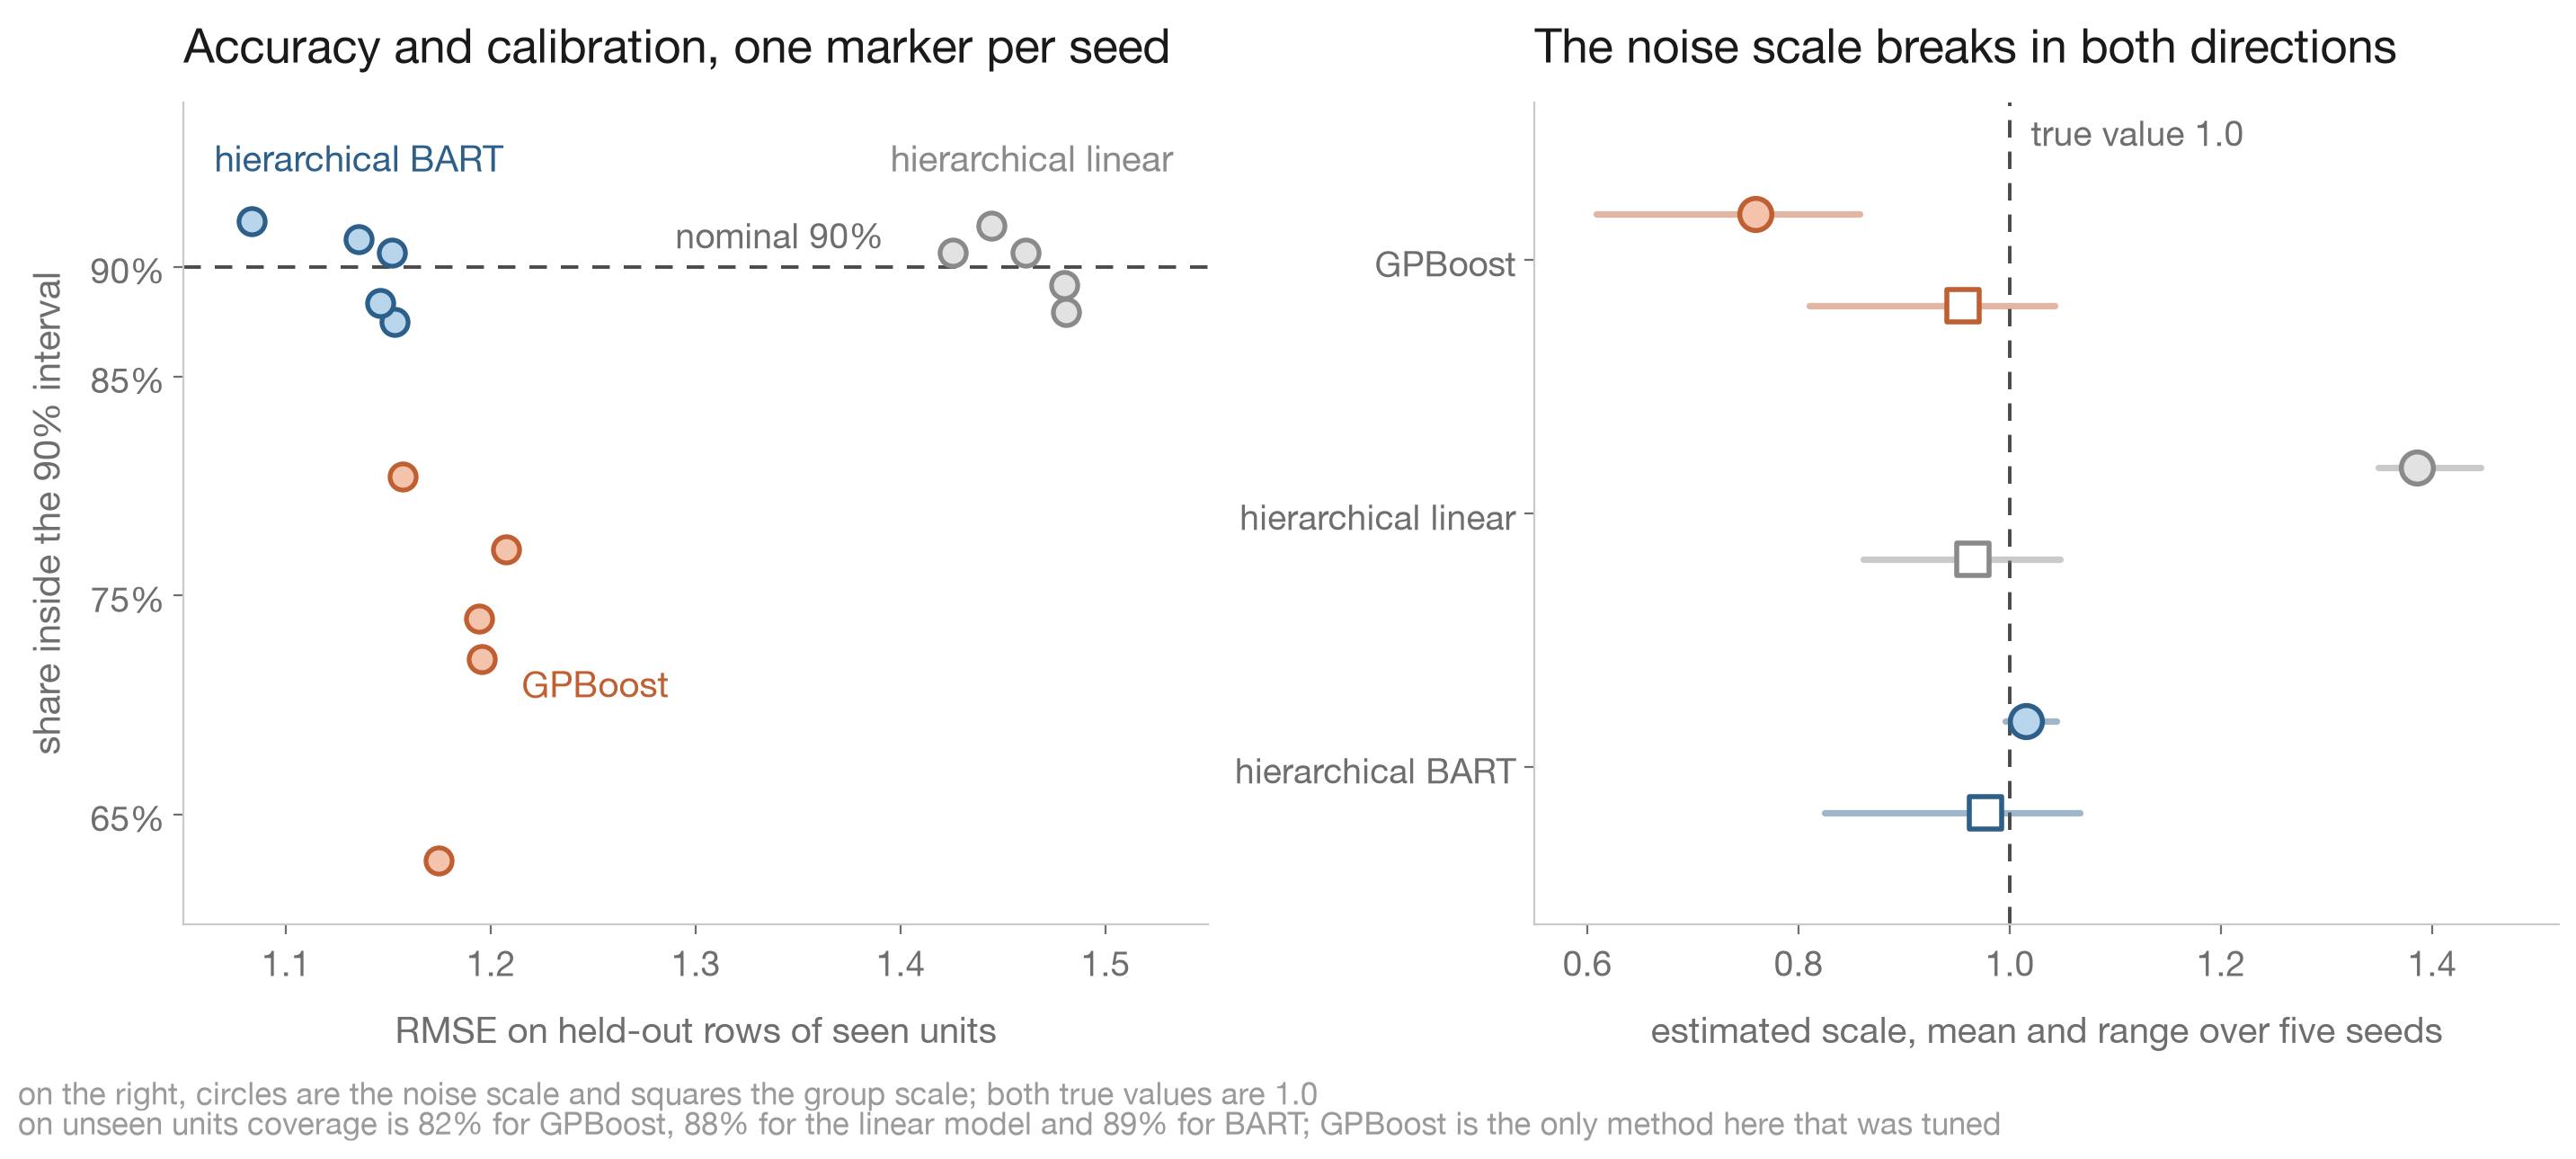

In [12]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
CORAL_F, CORAL_E = "#F4C3AC", "#C05F32"
BLUE_F, BLUE_E = "#B9D5EC", "#2C5F8A"
GREY_F, GREY_E = "#E2E2E2", "#8a8a8a"
INK, MUTED, FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"
# label, edge colour, fill colour, where the cluster label goes on the left panel
STYLE = [("GPBoost", CORAL_E, CORAL_F, (1.215, 0.700)),
         ("Hierarchical linear", GREY_E, GREY_F, (1.395, 0.940)),
         ("Hierarchical BART", BLUE_E, BLUE_F, (1.065, 0.940))]

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.4), dpi=200)
fig.patch.set_facecolor("white")

# left: accuracy against calibration, one marker per seed, seen units
ax = axes[0]
for model, ec, fc, at in STYLE:
    r = res[res.model == model]
    ax.scatter(r.rmse_seen, r.cov_seen, s=110, facecolor=fc, edgecolor=ec, lw=1.9, zorder=5)
    ax.text(at[0], at[1], model.replace("Hierarchical", "hierarchical"), fontsize=14.5,
            color=ec, ha="left", va="bottom")
ax.axhline(0.90, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.set_xlim(1.05, 1.55); ax.set_ylim(0.60, 0.975)
ax.set_yticks([0.65, 0.75, 0.85, 0.90]); ax.set_yticklabels(["65%", "75%", "85%", "90%"])
ax.text(1.29, 0.905, "nominal 90%", fontsize=14, color=MUTED, va="bottom", ha="left")
ax.set_xlabel("RMSE on held-out rows of seen units", fontsize=14.5, color=MUTED, labelpad=10)
ax.set_ylabel("share inside the 90% interval", fontsize=15, color=MUTED, labelpad=9)
ax.set_title("Accuracy and calibration, one marker per seed", fontsize=19, color=INK, pad=16,
             loc="left")

# right: which of the two scales each method recovers
ax = axes[1]
for i, (model, ec, fc, _) in enumerate(STYLE):
    r = res[res.model == model]
    for col, mark, filled in [("s", "o", True), ("s_b", "s", False)]:
        y = 2 - i + (0.18 if filled else -0.18)
        ax.plot([r[col].min(), r[col].max()], [y, y], color=ec, lw=2.6, alpha=0.45,
                solid_capstyle="round", zorder=3)
        ax.scatter([r[col].mean()], [y], s=165, marker=mark, edgecolor=ec, lw=2.0, zorder=5,
                   facecolor=fc if filled else "white")
ax.axvline(1.0, color="#4a4a4a", lw=1.4, ls=(0, (5, 4)), zorder=1)
ax.set_yticks([2, 1, 0])
ax.set_yticklabels([m.replace("Hierarchical", "hierarchical") for m, *_ in STYLE], fontsize=14.5)
ax.set_ylim(-0.62, 2.62); ax.set_xlim(0.55, 1.52)
ax.text(1.02, 2.58, "true value 1.0", fontsize=14, color=MUTED, va="top")
ax.set_xlabel("estimated scale, mean and range over five seeds", fontsize=14.5, color=MUTED,
              labelpad=10)
ax.set_title("The noise scale breaks in both directions", fontsize=19, color=INK, pad=16,
             loc="left")

for ax in axes:
    ax.tick_params(labelsize=14, colors=MUTED, length=4)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color("#c9c9c9")

fig.text(0.008, 0.032, "on the right, circles are the noise scale and squares the group scale; "
         "both true values are 1.0", fontsize=12.5, color=FAINT, ha="left")
fig.text(0.008, 0.006, "on unseen units coverage is 82% for GPBoost, 88% for the linear model and "
         "89% for BART; GPBoost is the only method here that was tuned", fontsize=12.5,
         color=FAINT, ha="left")
fig.tight_layout(rect=[0, 0.055, 1, 1.0])
fig.savefig("panel_pymc_hierarchical.png", facecolor="white")
plt.show()

## What this run shows

- The posterior predictive covers what it claims on seen units, and comes within two points of it on
  unseen ones. It integrates over the parameters, so the interval carries the error of the fitted
  mean rather than assuming it away, which is the term part 4 found missing from the tree methods.
- Reaching 90% is not on its own evidence that the decomposition is right. Part 4's out-of-sample
  GPBoost got there by overshooting the noise variance to 1.33, and the linear model here gets there
  by inflating the noise scale to absorb a mean function that cannot fit. Read the scale next to the
  coverage.
- An unseen unit needs a draw from the population of intercepts. Using the population mean instead
  is a one-character change that costs eight points of coverage with a linear mean and twelve with
  BART.
- Trees in the mean slot and a random intercept elsewhere recover both scales and beat the tuned
  GPBoost on accuracy at the same time, with no tuning at all. The cost is that BART's own sampler
  diagnostics stay poor while it does so, so it has to be judged on held-out coverage.
- The two standard precautions for hierarchical models are conditional, not universal. Measure the
  condition on your own panel before paying for either.

One synthetic panel with independent rows inside each unit, five seeds, and a single mean function
per model. Run the same check on your own data before trusting any of these intervals.